# Track-wise dataset — enriched 0.0625°, 30-minute, 1-minute decisions

This notebook analyzes the completed CPR-gating dataset. The preparation pipeline
has already run; the notebook loads `trackwise_decisions.parquet`, which now
contains the validated 40-column enriched schema. It does not re-run extraction.

The dataset supports the future RL problem: use GEOS-5 Nature Run diagnostic
proxies and geometry to decide whether to power the CPR, then score that action
against stored target diagnostics. The cloud and radiation fields are idealized
GEOS-5 proxies, not simulated EarthCARE retrievals.

| | final trackwise dataset |
|---|---|
| collection | `inst30mn_2d_met1_Nx` @ **0.0625°** |
| weather cadence | **30 min** |
| decision cadence | **1 min** |
| rows | **351,639** |
| source columns | 27 |
| enriched columns | **40** |
| decision discontinuities | **49** (1,161 missing decision IDs) |
| labels | CPR swath and nadir targets, retained but never ordinary observations |

The enriched additions are `lwtup_fore`, continuous nadir land/water fractions,
cyclic longitude (`sin_lon`, `cos_lon`), and eight target-validity flags. See
`docs/feature_set.md` and `docs/column_registry.yaml` for the complete feature
tiers and limitations.


> **Completed-dataset mode:** the extraction cells below document the original
configuration and remain useful for provenance, but should not be rerun for this
analysis. The notebook loader reads the validated local
`trackwise_decisions.parquet` directly. No weather download or re-extraction is
needed to reproduce the analysis and visuals.

The source parquet is now the enriched 40-column dataset. All joins and checks
in the preparation workflow used the `decision` key, preserving the 49 genuine
discontinuities rather than shifting rows across missing decision IDs.


In [1]:
# Dependencies are already installed; no package download is needed.

from datetime import datetime, timezone, timedelta
import os, gc, time as _time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- configuration -------------------------------------------------------
# ---- WEATHER WINDOW ----
# 8 months starting at the wettest point of the G5NR record. June-July 2005 is
# the wettest consecutive 2-month window (area-weighted global mean prectot from
# tavg01mo_2d_met3_Cx: 3.204 mm/day, highest of all 24 months), so a June start
# opens on peak monsoon/ITCZ and sweeps through NH autumn into winter, giving
# real seasonal spread instead of a single regime.
# The G5NR 30-min axis starts 2005-05-15 21:30, hence the offset:
FIELD_START = 773           # G5NR step of 2005-06-01 00:00
N_FIELDS    = 11760         # 245 days -> 2006-02-01 00:00 (exclusive)
DECISION    = timedelta(minutes=1)    # the CPR on/off decision interval
SUB_STEP    = timedelta(seconds=1)    # 1 s ~= 6.8 km ~= one 0.0625 deg cell:
                                      # gives a CONTIGUOUS nadir track
G5_STEP     = timedelta(minutes=30)   # G5NR native cadence

# Measured against NCCS (see the concurrency cell below):
#   * ~1.0 s per VARIABLE of latency -> a 13-var request costs ~14 s regardless of size
#   * ~0.058 MB/s PER CONNECTION -> big bboxes are ruinous (98 MB took 380 s), so
#     keep GROUP small; 10 small requests beat 1 large one by 2.6x
#   * per-request time is FLAT as connections are added (13.7 / 13.8 / 14.1 s at
#     1 / 3 / 6 workers) -> the cap is per-connection, so concurrency scales ~linearly
# Therefore the run time is (requests x 14 s) / WORKERS, and full 1-minute sampling
# is feasible given enough concurrency. No decision sampling is required.
DEC_PER_FIELD = 30          # 30 = EVERY 1-minute decision (no sampling)
GROUP         = 3           # decisions per request; keep small (bbox hugs the track)
WORKERS       = 18          # PROCESSES. Threads do NOT help (netCDF-C serialises).
                            # Measured on this M4/16GB box (aggregate MB/s vs serial):
                            #   6 -> 5.3x | 12 -> 9.4x | 24 -> 12.8x
                            # Scaling is near-linear to ~12 then flattens (NCCS
                            # appears to shape per source IP). 18 workers ~= 11.3x
                            # and ~2.6 GB RSS (142 MB each). On a cluster, more
                            # NODES (distinct IPs) beat more processes on one host.
PAUSE         = 0.0
CACHE         = "cache_8mo_jun2005"
CHECKPOINT    = 200         # fields per parquet part

G5NR_URL = ("https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/"
            "0.0625_deg/inst/inst30mn_2d_met1_Nx")

# MSI-observable -> may enter the agent's observation vector
MSI = ["tautot", "tauhgh", "taulow", "cldtot", "cldhgh", "cldmid",
       "cldlow", "cldtmp", "lwtup"]
# CPR / ground truth -> label only, NEVER a feature.
# `cape` dropped: 20-30% fill, never used as a feature, and ~1 s on every request
# (~3 h over the run). `precsno` dropped for the same reason.
LAB = ["prectot", "preccon", "iwp", "lwp"]
VARS = MSI + LAB
assert not (set(MSI) & set(LAB)), "a variable cannot be both feature and label"

startdate = datetime(2025, 7, 19, 15, 4, tzinfo=timezone.utc)   # ground-track clock
N_ROWS    = N_FIELDS * DEC_PER_FIELD

# decision indices actually sampled: DEC_PER_FIELD consecutive minutes per field
PER_FIELD = int(G5_STEP / DECISION)          # 30 decisions exist per field
DEC_PER_FIELD = min(DEC_PER_FIELD, PER_FIELD)
SAMPLED = np.array([f * PER_FIELD + k
                    for f in range(N_FIELDS) for k in range(DEC_PER_FIELD)])
N_REQ = int(np.ceil(len(SAMPLED) / GROUP))

_per_req = len(VARS) * 1.0 + 0.94 * len(VARS) / 15 / 0.27      # latency + transfer
N_ROWS = len(SAMPLED)
print(f"Jun 2005 - Jan 2006 | {N_FIELDS:,} weather fields x {DEC_PER_FIELD} "
      f"decisions = {N_ROWS:,} rows")
print(f"{len(VARS)} vars ({len(MSI)} features + {len(LAB)} labels)")
print(f"{N_REQ:,} requests x ~{_per_req:.0f}s = {N_REQ*_per_req/3600:.0f} h serial")
# Estimate from MEASURED BLOCK TIMES, not from a burst benchmark. Short bursts
# suggested 5.9 s/task (=> 194 h for 8 months); the real 2-month run averaged
# 18-31 min per 200-field block at 18 workers (~24 min), i.e. ~24 h for 8 months.
# Burst benchmarks on a throttled server proved unreliable in BOTH directions.
_BLOCK_MIN = 24
_nblocks = -(-N_FIELDS // CHECKPOINT)
print(f"    {_nblocks} blocks x ~{_BLOCK_MIN} min (measured) = "
      f"{_nblocks*_BLOCK_MIN/60:.0f} h ({_nblocks*_BLOCK_MIN/1440:.1f} days)")
print(f"    worker RSS ~142 MB -> ~{WORKERS*0.142:.1f} GB total")
print(f"output ~{N_ROWS*25*8/1e6:.0f} MB | peak memory ~1 MB per worker (one slab)")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Jun 2005 - Jan 2006 | 11,760 weather fields x 30 decisions = 352,800 rows
13 vars (9 features + 4 labels)
117,600 requests x ~16s = 523 h serial
    59 blocks x ~24 min (measured) = 24 h (1.0 days)
    worker RSS ~142 MB -> ~2.6 GB total
output ~71 MB | peak memory ~1 MB per worker (one slab)


In [2]:
from tatc import utils
from tatc.schemas import PointedInstrument, Satellite, TwoLineElements

earthcare = Satellite(
    name="EarthCare",
    orbit=TwoLineElements(tle=[
        "1 59908U 24101A   25200.34125573  .00010433  00000+0  14571-3 0  9999",
        "2 59908  97.0168 326.4971 0001222 108.6708 251.4681 15.57041891 64775",
    ]),
    instruments=[PointedInstrument(
        name="MSI",
        field_of_regard=utils.swath_width_to_field_of_regard(394e3, 150e3) + 2 * 5.760868,
        cross_track_field_of_view=utils.swath_width_to_field_of_view(394e3, 150e3, 5.760868),
        along_track_field_of_view=utils.swath_width_to_field_of_view(394e3, 10e3, 5.760868),
        roll_angle=5.760868, is_rectangular=True)],
)
satellites = [earthcare]


In [3]:
import xarray as xr

# HTTP.TIMEOUT turns a stalled DAP transfer into a catchable exception
_dodsrc = os.path.expanduser("~/.dodsrc")
if not (os.path.exists(_dodsrc) and "HTTP.TIMEOUT" in open(_dodsrc).read()):
    with open(_dodsrc, "a") as f:
        f.write("HTTP.TIMEOUT=300\n")
    print("added HTTP.TIMEOUT=300 to ~/.dodsrc (restart kernel if DAP already used)")

def open_g5nr():
    for a in range(5):
        try:
            return xr.open_dataset(G5NR_URL, decode_times=True)
        except Exception as e:
            print(f"open failed {a+1}/5: {e}", flush=True)
            _time.sleep(15 * (a + 1))
    raise RuntimeError("could not open G5NR")

dataset = open_g5nr()
g5_times = pd.to_datetime(dataset["time"].values)
g5_lat = dataset["lat"].values
g5_lon = dataset["lon"].values
print(f"{G5NR_URL.rsplit('/',1)[-1]}: {len(g5_times):,} steps, "
      f"{g5_times[0]} -> {g5_times[-1]}")
print(f"grid {len(g5_lat)} x {len(g5_lon)}  (dlat {abs(g5_lat[1]-g5_lat[0]):.4f}°)")
missing = [v for v in VARS if v not in dataset.variables]
assert not missing, f"not in this collection: {missing}"
print(f"all {len(VARS)} requested variables present")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


inst30mn_2d_met1_Nx: 36,576 steps, 2005-05-15 21:30:00 -> 2007-06-16 21:00:00
grid 2881 x 5760  (dlat 0.0625°)
all 13 requested variables present


In [4]:
from tatc.analysis import compute_ground_track
from joblib import Parallel, delayed
from skyfield.api import EarthSatellite, wgs84
from tatc.constants import timescale

SUB_PER_DEC = int(DECISION / SUB_STEP)

# Skip this cell's footprint/nadir precompute when every block is already
# cached: cell 7's fetch loop only consumes `tracks`/`nad_lat`/`nad_lon` inside
# its `for a,b in todo:` body, so if `todo` is empty this whole computation is
# unused work. For 8 months (352,800 decisions) doing it anyway crashed the
# kernel (OOM) on a consolidation-only run where nothing needed fetching.
_blocks = [(b, min(b + CHECKPOINT, N_FIELDS)) for b in range(0, N_FIELDS, CHECKPOINT)]
_todo = [(a, b) for a, b in _blocks
         if not os.path.exists(f"{CACHE}/rows_{a//CHECKPOINT:05d}.parquet")]

if not _todo:
    print(f"all {len(_blocks)} blocks already cached in {CACHE}/ -> skipping "
          f"footprint/nadir precompute (nothing left to fetch)")
    tracks = pd.DataFrame({"field": pd.Series(dtype="int64")})
    nad_lat = np.empty((0, 0), dtype="float32")
    nad_lon = np.empty((0, 0), dtype="float32")
    ROW_OF = {}
else:

    # footprints ONLY for the sampled decisions (not all 349,920)
    def one_decision(i):
        t0 = startdate + int(i) * DECISION
        return compute_ground_track(
            satellites[0],
            pd.date_range(t0, t0 + DECISION, freq=SUB_STEP, inclusive="left"),
            crs="spice")

    _t0 = _time.time()
    tracks = pd.concat(Parallel(-1)(delayed(one_decision)(i) for i in SAMPLED),
                       ignore_index=True)
    tracks["decision"] = SAMPLED
    tracks["field"] = SAMPLED // PER_FIELD
    _g = tracks.geometry.iloc[0]
    print(f"{len(tracks):,} sampled footprints in {_time.time()-_t0:.0f}s "
          f"({_g.geom_type})")

    # nadir sub-satellite points for those decisions only
    _t0 = _time.time()
    _sf = EarthSatellite(satellites[0].orbit.tle[0], satellites[0].orbit.tle[1],
                         "EarthCare", timescale)
    _off = np.arange(SUB_PER_DEC) * SUB_STEP.total_seconds()
    _secs = (SAMPLED[:, None] * DECISION.total_seconds() + _off[None, :]).ravel()
    _ts = timescale.from_datetimes(
        pd.to_datetime(startdate) + pd.to_timedelta(_secs, unit="s"))
    _sp = wgs84.subpoint(_sf.at(_ts))
    nad_lat = _sp.latitude.degrees.astype("float32").reshape(len(SAMPLED), SUB_PER_DEC)
    nad_lon = _sp.longitude.degrees.astype("float32").reshape(len(SAMPLED), SUB_PER_DEC)
    del _sp, _ts, _secs; gc.collect()
    _d = np.hypot(np.diff(nad_lat[0]) * 111.32,
                  np.diff(nad_lon[0]) * 111.32 * np.cos(np.radians(nad_lat[0][:-1])))
    print(f"nadir: {nad_lat.size:,} points in {_time.time()-_t0:.0f}s "
          f"({nad_lat.nbytes*2/1e6:.0f} MB) | spacing {_d.mean():.2f} km "
          f"-> {'contiguous' if _d.mean() <= 1.5*0.0625*111.32 else 'GAPS'}")

    # decision -> row index in nad_lat/nad_lon
    ROW_OF = {int(d): i for i, d in enumerate(SAMPLED)}


all 59 blocks already cached in cache_8mo_jun2005/ -> skipping footprint/nadir precompute (nothing left to fetch)


## Streaming extraction

For each group of `GROUP` consecutive decisions:

1. take the union bounding box (consecutive 1-minute segments are nearly collinear, so
   the box hugs the track — this is why `GROUP` is small)
2. fetch that slab for the nearest 30-minute timestep
3. reduce each decision to **one row**: MSI features averaged over the swath, labels taken
   as the peak over the swath *and* separately over the nadir track
4. free the slab

Nothing global is ever materialised, so memory is flat in the length of the run. Parts are
checkpointed to parquet, so a rerun resumes.

In [5]:
import shapely
from joblib import Parallel, delayed

os.makedirs(CACHE, exist_ok=True)

# Field f maps to G5NR time index f exactly (one field == one 30-min step), so the
# time mapping is pure index arithmetic. NEVER match datetimes: ground-track times
# are on a 2025 TLE clock and the G5NR axis is 2005-2007, so nearest-datetime
# collapses every request onto the last step (that bug produced a 1-field dataset).
assert FIELD_START + N_FIELDS <= len(g5_times), "window exceeds the G5NR axis"
print(f"time map: field 0..{N_FIELDS-1} -> G5NR steps "
      f"{FIELD_START}..{FIELD_START+N_FIELDS-1} = "
      f"{g5_times[FIELD_START]} .. {g5_times[FIELD_START+N_FIELDS-1]}")

_WDS = None
def _wds(force=False):
    """One DAP handle per worker, reused; `force` discards a dead one.

    The reset MUST go through this function's own `global _WDS`. An earlier
    version did `globals()["_WDS"] = None` from inside process_field; under
    cloudpickle that resolves to a different namespace, so the reset silently
    did nothing -- a worker whose handle died (laptop sleep) kept handing back
    that dead handle and every later task timed out. Cost: 18 workers, 10 hours,
    zero rows, against a perfectly healthy server.
    """
    global _WDS
    if force and _WDS is not None:
        try:
            _WDS.close()
        except Exception:
            pass
        _WDS = None
    if _WDS is None:
        import xarray as xr
        _WDS = xr.open_dataset(G5NR_URL, decode_times=True)
    return _WDS

# np.isfinite() alone lets through a handful of G5NR cells that return a
# large-but-technically-finite fill value (up to ~3.4e38, float32's max) for
# missing data -- caught 640 rows in the 8mo dataset, e.g. a "cloud fraction"
# of 1.3e35. No MSI/label variable here is ever physically close to 1e6.
def _sane(a):
    return a[np.isfinite(a) & (np.abs(a) < 1e6)]

def _nanmax(a):
    a = _sane(a)
    return float(a.max()) if a.size else float("nan")

def _nanmean(a):
    a = _sane(a)
    return float(a.mean()) if a.size else float("nan")

def reduce_decision(geom, sub, nlat, nlon):
    la = sub["lat"].values; lo = sub["lon"].values
    if la.size == 0 or lo.size == 0:
        return None
    LO, LA = np.meshgrid(lo, la)
    inside = shapely.contains_xy(geom, LO, LA)
    if not inside.any():
        c = geom.centroid
        inside = np.zeros_like(LO, dtype=bool)
        inside[np.abs(la - c.y).argmin(), np.abs(lo - c.x).argmin()] = True
    keep = ((nlat >= la.min()) & (nlat <= la.max())
            & (nlon >= lo.min()) & (nlon <= lo.max()))
    if not keep.any():
        keep = np.ones_like(nlat, dtype=bool)
    ni = np.abs(la[:, None] - nlat[keep][None, :]).argmin(axis=0)
    nj = np.abs(lo[:, None] - nlon[keep][None, :]).argmin(axis=0)
    row = {}
    for v in MSI:
        row[f"{v}_mean"] = _nanmean(sub[v].values[inside])
    row["tautot_max"] = _nanmax(sub["tautot"].values[inside])
    for v in LAB:
        arr = sub[v].values
        row[f"{v}_swath"] = _nanmax(arr[inside])
        row[f"{v}_nadir"] = _nanmax(arr[ni, nj])
    row["n_swath_cells"] = int(inside.sum())
    row["n_nadir_cells"] = len(set(zip(ni, nj)))
    return row

def process_field(fi, geoms, decs, times, nlats, nlons):
    """One 30-min field -> rows. Runs in a worker process.
    `fi` is the RELATIVE field index; absolute G5NR time index = FIELD_START + fi."""
    import xarray as xr
    g5i = FIELD_START + fi
    pad = 0.13
    xs = [g.bounds for g in geoms]
    lat0 = min(b[1] for b in xs); lat1 = max(b[3] for b in xs)
    lon0 = min(b[0] for b in xs); lon1 = max(b[2] for b in xs)
    sub = None
    for a in range(4):
        try:
            ds = _wds(force=(a > 0))   # retries always get a FRESH handle
            sel = dict(lat=slice(lat0 - pad, lat1 + pad))
            if lon1 - lon0 > 180:
                w = ds[VARS].isel(time=g5i).sel(lon=slice(120, 180), **sel).load()
                e = ds[VARS].isel(time=g5i).sel(lon=slice(-180, -120), **sel).load()
                sub = xr.concat([w, e], dim="lon")
            else:
                sub = ds[VARS].isel(time=g5i).sel(
                    lon=slice(lon0 - pad, lon1 + pad), **sel).load()
            break
        except Exception:
            _time.sleep(min(4 * 2 ** a, 45))
    if sub is None:
        return []
    out = []
    for g, d, t, nla, nlo in zip(geoms, decs, times, nlats, nlons):
        r = reduce_decision(g, sub, nla, nlo)
        if r is None:
            continue
        r.update(decision=int(d), field=int(fi), g5_step=int(g5i),
                 time=t, lat=g.centroid.y, lon=g.centroid.x)
        out.append(r)
    return out

# One TASK = up to GROUP consecutive decisions inside one field. They share the
# field's G5NR step, and a short segment keeps the bbox tight around the track.
by_field = {f: g for f, g in tracks.groupby("field")}
blocks = [(b, min(b + CHECKPOINT, N_FIELDS)) for b in range(0, N_FIELDS, CHECKPOINT)]
todo = [(a, b) for a, b in blocks
        if not os.path.exists(f"{CACHE}/rows_{a//CHECKPOINT:05d}.parquet")]
print(f"{len(blocks)} blocks | {len(blocks)-len(todo)} cached | {len(todo)} to fetch")
print(f"{N_REQ:,} requests total, {WORKERS} concurrent")

_t0 = _time.time()
for a, b in todo:
    args = []
    for fi in range(a, b):
        seg = by_field.get(fi)
        if seg is None or len(seg) == 0:
            continue
        seg = seg.sort_values("decision")
        for s in range(0, len(seg), GROUP):          # split field into small bboxes
            ch = seg.iloc[s:s + GROUP]
            rows_i = [ROW_OF[int(d)] for d in ch.decision]
            args.append((fi, list(ch.geometry), list(ch.decision), list(ch.time),
                         [nad_lat[i] for i in rows_i], [nad_lon[i] for i in rows_i]))
    res = Parallel(n_jobs=WORKERS, backend="loky", verbose=0)(
        delayed(process_field)(*x) for x in args)
    flat = [r for rs in res for r in rs]
    if flat:
        pd.DataFrame(flat).to_parquet(
            f"{CACHE}/rows_{a//CHECKPOINT:05d}.parquet", index=False)
    el = _time.time() - _t0
    dn = (a - todo[0][0]) // CHECKPOINT + 1
    print(f"  block {a//CHECKPOINT}: {len(flat):,} rows | {el/60:.0f} min "
          f"| eta {el/dn*(len(todo)-dn)/3600:.1f} h", flush=True)
    del res, flat; gc.collect()
print(f"\ndone in {(_time.time()-_t0)/3600:.1f} h")


time map: field 0..11759 -> G5NR steps 773..12532 = 2005-06-01 00:00:00 .. 2006-01-31 23:30:00
59 blocks | 59 cached | 0 to fetch
117,600 requests total, 18 concurrent

done in 0.0 h


In [2]:
# ---- load the completed enriched dataset -------------------------------
# This cell is analysis-only: it does not concatenate extraction cache parts,
# contact OPeNDAP, or rewrite the source parquet.
DATASET_PATH = "trackwise_decisions.parquet"
rows = pd.read_parquet(DATASET_PATH)
EXPECTED_ROWS, EXPECTED_COLS = 351_639, 40
assert rows.shape == (EXPECTED_ROWS, EXPECTED_COLS), rows.shape
assert rows.decision.is_unique
assert rows.decision.diff().fillna(1).ge(0).all()
assert rows.g5_step.nunique() > 1

validity_flags = [
    "prectot_swath_valid", "prectot_nadir_valid",
    "preccon_swath_valid", "preccon_nadir_valid",
    "iwp_swath_valid", "iwp_nadir_valid",
    "lwp_swath_valid", "lwp_nadir_valid",
]
assert set(validity_flags).issubset(rows.columns)
print(f"loaded {len(rows):,} rows x {rows.shape[1]} enriched columns")
print(f"weather fields: {rows.field.nunique():,} | decision discontinuities: {(rows.decision.diff().dropna() != 1).sum():,}")
print(f"target-invalid entries: {(~rows[validity_flags]).sum().sum():,} | "
      f"decisions with any invalid target: {(~rows[validity_flags].all(axis=1)).sum():,}")
print(f"mixed-surface decisions (0.05 < land_frac_nadir < 0.95): "
      f"{((rows.land_frac_nadir > .05) & (rows.land_frac_nadir < .95)).mean()*100:.2f}%")
rows.head()


loaded 351,639 rows x 40 enriched columns
weather fields: 11,731 | decision discontinuities: 49
target-invalid entries: 94 | decisions with any invalid target: 51
mixed-surface decisions (0.05 < land_frac_nadir < 0.95): 17.09%


,tautot_mean,tauhgh_mean,taulow_mean,cldtot_mean,cldhgh_mean,cldmid_mean,cldlow_mean,cldtmp_mean,lwtup_mean,tautot_max,...,sin_lon,cos_lon,prectot_swath_valid,prectot_nadir_valid,preccon_swath_valid,preccon_nadir_valid,iwp_swath_valid,iwp_nadir_valid,lwp_swath_valid,lwp_nadir_valid
0,2.063310,1.337723,0.696106,0.269774,0.268247,0.001255,0.000842,214.231064,276.398682,73.3750,...,-0.259589,0.965719,True,True,True,True,True,True,True,True
1,38.658318,7.217800,29.732626,0.668513,0.610194,0.009806,0.135548,213.349991,215.204880,136.2500,...,-0.272181,0.962246,True,True,True,True,True,True,True,True
2,34.254906,1.743874,24.986034,0.774976,0.496218,0.005107,0.488598,232.473862,264.373444,166.7500,...,-0.284522,0.958670,True,True,True,True,True,True,True,True
3,19.846237,0.000362,19.845877,0.380796,0.002244,0.000091,0.380153,290.432922,289.106873,60.5625,...,-0.296689,0.954974,True,True,True,True,True,True,True,True
4,24.778891,0.044492,24.734325,0.493994,0.185658,0.000005,0.397964,281.380066,284.057434,94.8750,...,-0.308757,0.951141,True,True,True,True,True,True,True,True


In [3]:
# ---- CLASS BALANCE: valid swath vs nadir targets -----------------------
MM = 3600.0     # kg m-2 s-1 -> mm/hr
print(f"{len(rows):,} decisions ({DECISION.total_seconds()/60:.0f}-minute interval)\n")
print(f"{'threshold':<20}{'prectot swath':>20}{'prectot nadir':>20}"
      f"{'preccon swath':>20}{'preccon nadir':>20}")
for nm, mm in [("any > 0", 0.0), (">= 0.1 mm/hr", 0.1), (">= 0.5 mm/hr", 0.5),
               (">= 1 mm/hr", 1.0), (">= 5 mm/hr", 5.0), (">= 10 mm/hr", 10.0)]:
    t = mm / MM
    cells = []
    for c in ["prectot_swath", "prectot_nadir", "preccon_swath", "preccon_nadir"]:
        valid = rows[c + "_valid"]
        p = 100 * (rows.loc[valid, c] > t).mean()
        cells.append(f"{int((rows.loc[valid, c] > t).sum()):>7,} ({p:4.1f}%, n={int(valid.sum()):,})")
    print(f"  {nm:<18}" + "".join(f"{c:>20}" for c in cells))

print("\nThe nadir column is what the CPR would actually measure; the swath column")
print("credits it with precipitation it never flies over. Validity flags exclude")
print("missing/corrupt targets from every positive-rate calculation.")
for c in ["prectot_swath", "prectot_nadir"]:
    valid = rows[c + "_valid"]
    r = (rows.loc[valid, c] > 1.0 / MM).mean()
    print(f"  {c:<15} at >=1 mm/hr: {100*r:.1f}% positive among {int(valid.sum()):,} valid targets")


351,639 decisions (1-minute interval)

threshold                  prectot swath       prectot nadir       preccon swath       preccon nadir
  any > 0           346,290 (98.5%, n=351,613)342,411 (97.4%, n=351,615)168,231 (47.8%, n=351,629)142,298 (40.5%, n=351,629)
  >= 0.1 mm/hr      233,162 (66.3%, n=351,613)171,006 (48.6%, n=351,615) 80,345 (22.8%, n=351,629) 54,220 (15.4%, n=351,629)
  >= 0.5 mm/hr      143,158 (40.7%, n=351,613) 75,417 (21.4%, n=351,615) 30,201 ( 8.6%, n=351,629) 10,058 ( 2.9%, n=351,629)
  >= 1 mm/hr        101,736 (28.9%, n=351,613) 45,599 (13.0%, n=351,615) 15,659 ( 4.5%, n=351,629)  3,625 ( 1.0%, n=351,629)
  >= 5 mm/hr         38,919 (11.1%, n=351,613) 12,151 ( 3.5%, n=351,615)  5,509 ( 1.6%, n=351,629)    697 ( 0.2%, n=351,629)
  >= 10 mm/hr        24,367 ( 6.9%, n=351,613)  6,486 ( 1.8%, n=351,615)  2,737 ( 0.8%, n=351,629)    273 ( 0.1%, n=351,629)

The nadir column is what the CPR would actually measure; the swath column
credits it with precipitation it ne

In [4]:
# ---- learnability: always-available features vs valid targets ------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# These are the registry's always-available candidates. CPR-conditional
# diagnostics and target columns are deliberately excluded.
FEATS = [
    "cldtot_mean", "cldtmp_mean", "tautot_mean", "tautot_max",
    "lwtup_mean", "lwtup_fore", "solar_hour", "lat", "sin_lon", "cos_lon",
    "land_frac_nadir", "ocean_frac_nadir",
]

def auc(score, y):
    m = np.isfinite(score)
    return roc_auc_score(y[m], score[m]) if len(set(y[m])) == 2 else float("nan")

for lab in ["prectot_nadir", "prectot_swath"]:
    valid = rows[lab + "_valid"].to_numpy()
    y = (rows.loc[valid, lab] > 1.0 / MM).astype(int).to_numpy()
    print(f"\n=== label: {lab} >= 1 mm/hr ({100*y.mean():.1f}% positive; {len(y):,} valid rows) ===")
    scored = []
    for f in FEATS:
        score = rows.loc[valid, f].to_numpy(dtype=float)
        scored.append((auc(score, y), f))
    sk = sorted(scored, key=lambda z: -abs((z[0] if np.isfinite(z[0]) else .5) - .5))
    for a, f in sk[:8]:
        print(f"  {f:<20}{a:6.3f}" + (f"   (inverted {1-a:.3f})" if a < 0.5 else ""))

valid = rows["prectot_nadir_valid"].to_numpy()
X = rows.loc[valid, FEATS].replace([np.inf, -np.inf], np.nan)
X = ((X - X.mean()) / X.std()).fillna(0).values
y = (rows.loc[valid, "prectot_nadir"] > 1.0 / MM).astype(int).values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=0, stratify=y)
clf = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear").fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]
print(f"\nlogistic on {len(FEATS)} always-available features -> valid nadir prectot >= 1 mm/hr")
print(f"  ROC-AUC {roc_auc_score(yte,p):.3f} | avg-precision "
      f"{average_precision_score(yte,p):.3f} (base rate {yte.mean():.3f})")



=== label: prectot_nadir >= 1 mm/hr (13.0% positive; 351,615 valid rows) ===


  tautot_mean          0.815
  tautot_max           0.789
  cldtot_mean          0.651
  cldtmp_mean          0.378   (inverted 0.622)
  lwtup_mean           0.402   (inverted 0.598)
  ocean_frac_nadir     0.572
  land_frac_nadir      0.431   (inverted 0.569)
  cos_lon              0.463   (inverted 0.537)

=== label: prectot_swath >= 1 mm/hr (28.9% positive; 351,613 valid rows) ===


  tautot_mean          0.829
  tautot_max           0.822
  cldtot_mean          0.600
  ocean_frac_nadir     0.590
  land_frac_nadir      0.413   (inverted 0.587)
  cldtmp_mean          0.435   (inverted 0.565)
  cos_lon              0.455   (inverted 0.545)
  lwtup_fore           0.533



logistic on 12 always-available features -> valid nadir prectot >= 1 mm/hr
  ROC-AUC 0.837 | avg-precision 0.368 (base rate 0.130)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


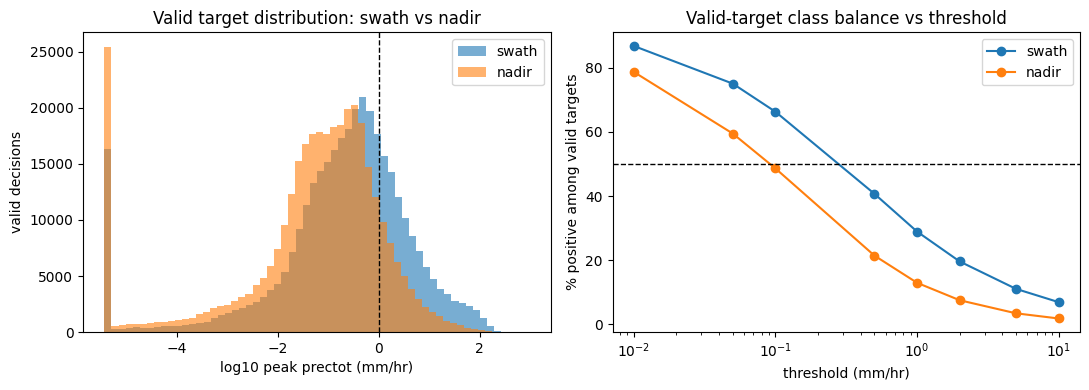

In [5]:
# ---- valid-target distributions and class balance ----------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
MM = 3600.0
sw = rows.loc[rows.prectot_swath_valid, "prectot_swath"].clip(lower=1e-9)
na = rows.loc[rows.prectot_nadir_valid, "prectot_nadir"].clip(lower=1e-9)
ax[0].hist(np.log10(sw * MM), bins=60, alpha=.6, label="swath")
ax[0].hist(np.log10(na * MM), bins=60, alpha=.6, label="nadir")
ax[0].axvline(0, color="k", ls="--", lw=1)
ax[0].set_xlabel("log10 peak prectot (mm/hr)"); ax[0].set_ylabel("valid decisions")
ax[0].set_title("Valid target distribution: swath vs nadir"); ax[0].legend()

th = np.array([0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10])
for c, lb in [("prectot_swath", "swath"), ("prectot_nadir", "nadir")]:
    valid = rows[c + "_valid"]
    ax[1].plot(th, [100 * (rows.loc[valid, c] > t / MM).mean() for t in th],
                marker="o", label=lb)
ax[1].axhline(50, color="k", ls="--", lw=1)
ax[1].set_xscale("log"); ax[1].set_xlabel("threshold (mm/hr)")
ax[1].set_ylabel("% positive among valid targets")
ax[1].set_title("Valid-target class balance vs threshold"); ax[1].legend()
plt.tight_layout(); plt.show()


## Visuals and exports\n\nRun these after the loader cell once `cache_junjul2005/` has parts.

balanced threshold: 0.092 mm/hr (50.0% positive)


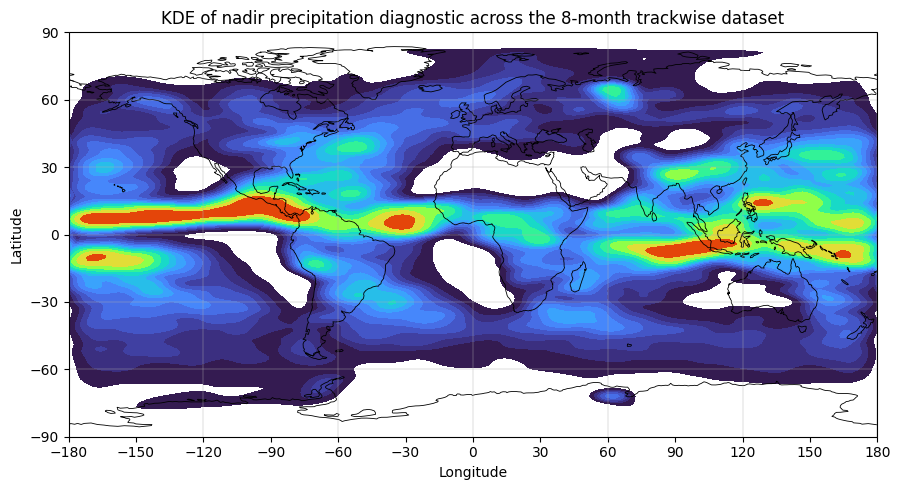

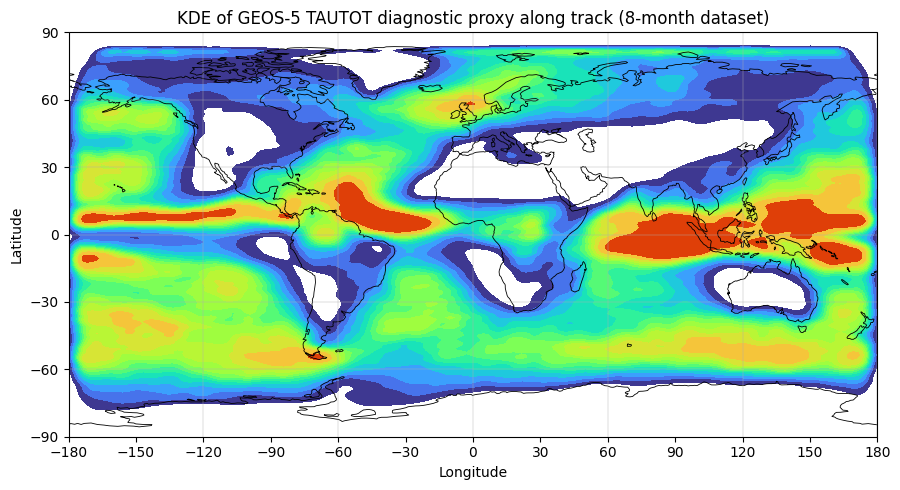

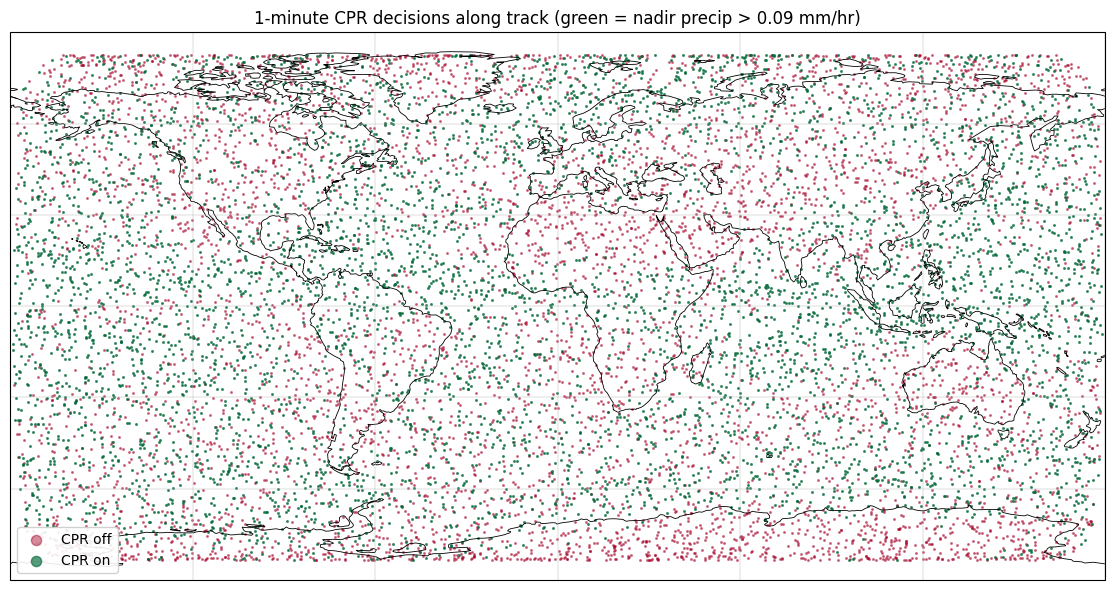

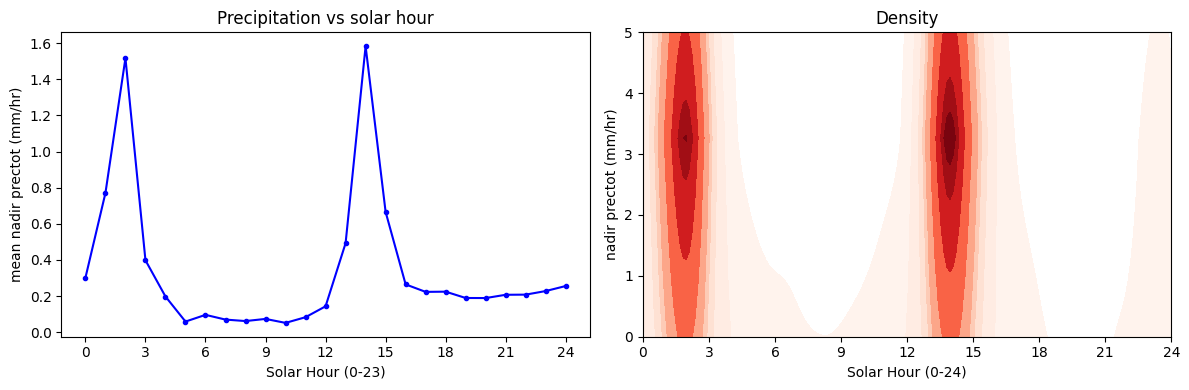

,decisions,CPR-on %,mean mm/hr
lat,,,
<-75,26742,12.89,0.07
-75:-45,61070,52.66,0.45
-45:-15,59001,49.66,0.97
tropics,58679,71.34,2.56
15:45,58969,47.95,1.26
45:75,61332,49.97,0.65
>75,25846,39.13,0.20


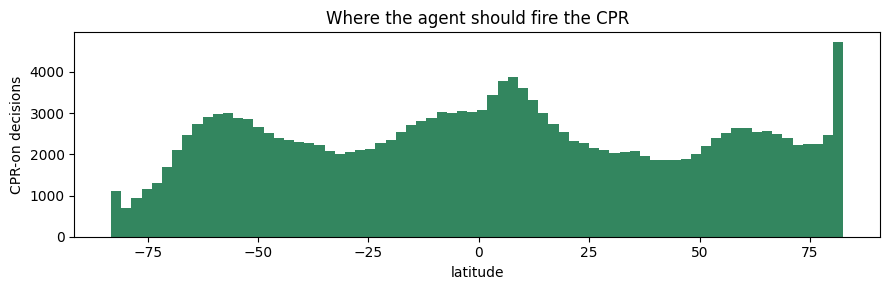

In [6]:
# ---- cartopy visuals (ports of the original notebook's figures) ----
# Dependencies are already installed; no package download is needed.
import seaborn as sns
import cartopy.crs as ccrs
import matplotlib.colors as mcolors

MM = 3600.0
THR = rows.loc[rows.prectot_nadir_valid, "prectot_nadir"].quantile(0.50)      # balanced valid-target label
print(f"balanced threshold: {THR*MM:.3f} mm/hr "
      f"({100*(rows.prectot_nadir>THR).mean():.1f}% positive)")
rows["fire"] = np.nan
rows.loc[rows.prectot_nadir_valid, "fire"] = (rows.loc[rows.prectot_nadir_valid, "prectot_nadir"] > THR).astype(int)

# --- 1-2. KDE maps: precipitation, then cloud cover (originals 17-19) ---
for col, w, title in [
    ("prectot_nadir", None, "KDE of nadir precipitation diagnostic across the 8-month trackwise dataset"),
    ("tautot_mean",   None, "KDE of GEOS-5 TAUTOT diagnostic proxy along track (8-month dataset)"),
]:
    d = rows[np.isfinite(rows[col]) & (rows[col] > 0)]
    fig, ax = plt.subplots(figsize=(11, 5), subplot_kw={"projection": ccrs.PlateCarree()})
    try:
        sns.kdeplot(data=d, x="lon", y="lat", weights=col, fill=True,
                    cmap="turbo", bw_adjust=0.25, levels=14, ax=ax)
    except ValueError as e:
        # degenerate density (skewed weights can make contour levels
        # non-increasing) -- fall back to a weighted hexbin, same data
        print(f"  kdeplot degenerate ({e}); falling back to hexbin for {col!r}")
        ax.hexbin(d["lon"], d["lat"], C=d[col], gridsize=180, cmap="turbo",
                  transform=ccrs.PlateCarree(), reduce_C_function=np.sum)
    ax.coastlines(linewidth=0.6); ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_title(title); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xticks(range(-180, 181, 30)); ax.set_yticks(range(-90, 91, 30))
    ax.gridlines(draw_labels=False, linewidth=0.3)
    plt.tight_layout(); plt.show()

# --- 3. decisions along track, coloured by the CPR decision (replaces the old
#        observed/unobserved cluster animation) ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})
sub = rows.iloc[::max(len(rows)//12000, 1)]          # thin for legibility
ax.scatter(sub.loc[sub.fire == 0, "lon"], sub.loc[sub.fire == 0, "lat"],
           s=1.5, c="#A50026", alpha=.45, transform=ccrs.PlateCarree(), label="CPR off")
ax.scatter(sub.loc[sub.fire == 1, "lon"], sub.loc[sub.fire == 1, "lat"],
           s=1.5, c="#006837", alpha=.65, transform=ccrs.PlateCarree(), label="CPR on")
ax.coastlines(linewidth=0.6); ax.set_global()
ax.set_title(f"1-minute CPR decisions along track "
             f"(green = nadir precip > {THR*MM:.2f} mm/hr)")
ax.gridlines(draw_labels=False, linewidth=0.3)
ax.legend(loc="lower left", markerscale=6, framealpha=.9)
plt.tight_layout(); plt.show()

# --- 4. precipitation vs solar hour (originals 15-16) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
h = rows.assign(sh=rows.solar_hour.round()).groupby("sh").agg(
        m=("prectot_nadir", "mean"), p=("fire", "mean")).reset_index()
ax[0].plot(h.sh, h.m * MM, marker=".", color="b")
ax[0].set_xlabel("Solar Hour (0-23)"); ax[0].set_ylabel("mean nadir prectot (mm/hr)")
ax[0].set_title("Precipitation vs solar hour"); ax[0].set_xticks(range(0, 25, 3))
try:
    sns.kdeplot(data=rows, x="solar_hour", y=rows.prectot_nadir*MM, fill=True,
                cmap="Reds", bw_adjust=0.6, ax=ax[1])
except ValueError as e:
    print(f"  kdeplot degenerate ({e}); falling back to hexbin")
    ax[1].hexbin(rows.solar_hour, rows.prectot_nadir*MM, gridsize=60, cmap="Reds")
ax[1].set_xlim(0, 23); ax[1].set_ylim(0, 5); ax[1].set_xticks(range(0, 25, 3))
ax[1].set_xlabel("Solar Hour (0-24)"); ax[1].set_ylabel("nadir prectot (mm/hr)")
ax[1].set_title("Density")
plt.tight_layout(); plt.show()

# --- 5. latitude bands (original 24) ---
band = pd.cut(rows.lat, [-90,-75,-45,-15,15,45,75,90],
              labels=["<-75","-75:-45","-45:-15","tropics","15:45","45:75",">75"],
              include_lowest=True)
rep = pd.DataFrame({"decisions": rows.groupby(band, observed=True).size(),
                    "CPR-on %": 100*rows.fire.groupby(band, observed=True).mean(),
                    "mean mm/hr": MM*rows.prectot_nadir.groupby(band, observed=True).mean()})
display(rep.round(2))
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(rows.loc[rows.fire==1, "lat"], bins=72, color="#006837", alpha=.8)
ax.set_xlabel("latitude"); ax.set_ylabel("CPR-on decisions")
ax.set_title("Where the agent should fire the CPR")
plt.tight_layout(); plt.show()


## Enriched-dataset diagnostics

These visuals are derived from the final 40-column parquet. They make the target
validity mask, static land/water context, cyclic longitude representation, and
verified one-minute sequential structure visible before any RL environment is
built.


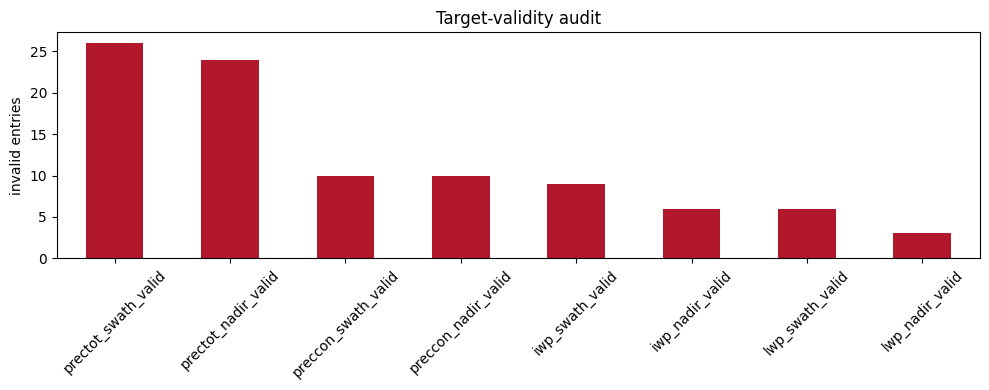

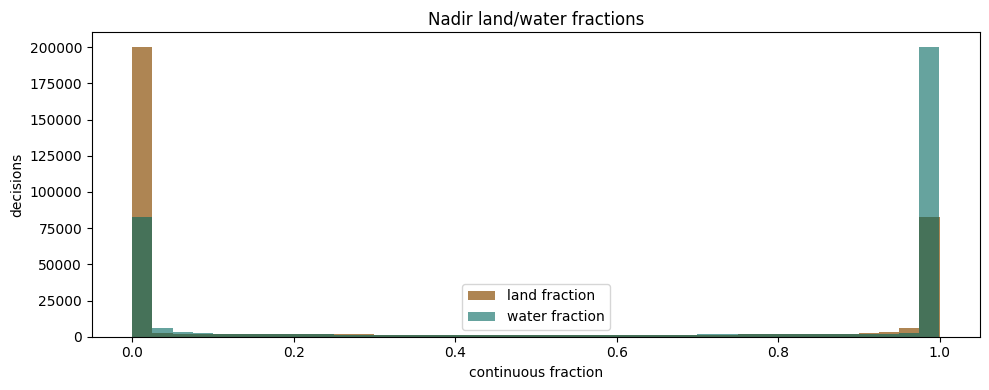

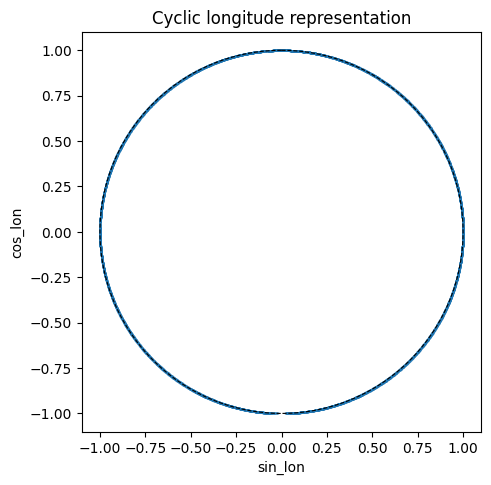

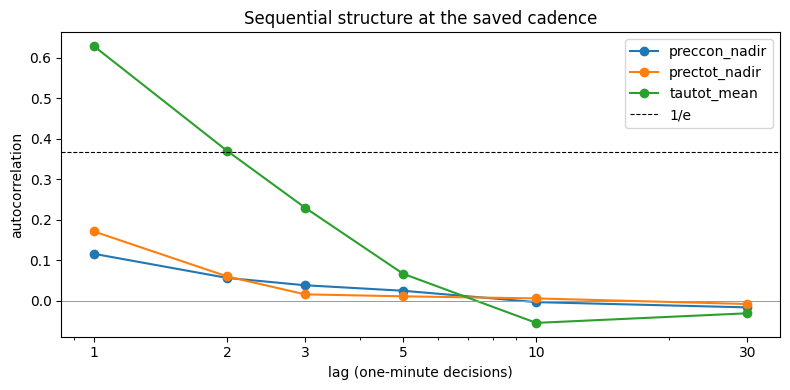

In [7]:
# ---- enriched diagnostics: validity, surface, longitude, autocorrelation ----
import seaborn as sns

# 1. Missing/corrupt target validity counts. False means missing or a finite
#    abs(value) >= 1e6 sentinel; no target is imputed.
invalid_counts = (~rows[validity_flags]).sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
invalid_counts.plot.bar(ax=ax, color="#b2182b")
ax.set_ylabel("invalid entries"); ax.set_title("Target-validity audit")
ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

# 2. Continuous surface fractions. Mixed-surface decisions are defined as
#    0.05 < land_frac_nadir < 0.95; they average 60 one-second samples and are
#    not necessarily individual shoreline grid cells.
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rows.land_frac_nadir, bins=40, alpha=.7, label="land fraction", color="#8c510a")
ax.hist(rows.ocean_frac_nadir, bins=40, alpha=.6, label="water fraction", color="#01665e")
ax.set_xlabel("continuous fraction"); ax.set_ylabel("decisions")
ax.set_title("Nadir land/water fractions"); ax.legend(); plt.tight_layout(); plt.show()

# 3. Longitude seam check: raw longitude is retained, while sin/cos encode it
#    continuously around +/-180 degrees.
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rows.sin_lon.iloc[::20], rows.cos_lon.iloc[::20], s=.5, alpha=.2)
t = np.linspace(0, 2*np.pi, 400); ax.plot(np.sin(t), np.cos(t), "k--", lw=.8)
ax.set_aspect("equal"); ax.set_xlabel("sin_lon"); ax.set_ylabel("cos_lon")
ax.set_title("Cyclic longitude representation"); plt.tight_layout(); plt.show()

# 4. Verified autocorrelation diagnostic. Pairs crossing decision gaps were
#    excluded before calculating these values.
acf = {
    "preccon_nadir": [0.116024, 0.056602, 0.038470, 0.024907, -0.003190, -0.016144],
    "prectot_nadir": [0.171179, 0.060293, 0.015995, 0.011164, 0.005938, -0.007796],
    "tautot_mean": [0.628451, 0.370135, 0.229986, 0.066772, -0.054396, -0.030714],
}
lags = [1, 2, 3, 5, 10, 30]
fig, ax = plt.subplots(figsize=(8, 4))
for name, values in acf.items(): ax.plot(lags, values, marker="o", label=name)
ax.axhline(np.exp(-1), color="k", ls="--", lw=.8, label="1/e")
ax.axhline(0, color="0.6", lw=.7); ax.set_xscale("log")
ax.set_xticks(lags); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("lag (one-minute decisions)"); ax.set_ylabel("autocorrelation")
ax.set_title("Sequential structure at the saved cadence"); ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
# ---- exports ----------------------------------------------------------
# CZML is the deliverable here: Cesium needs TIME-DYNAMIC data to animate an
# orbit. (GeoJSON is static and cannot express "the satellite is here at t" —
# that is why it is not produced.) CSV is kept for kepler.gl / analysis.
import json as _json

MM  = 3600.0
ALT = 394_000.0            # EarthCARE mean altitude, metres
CZML_DAYS   = 3            # animate this many days; ~0.25 MB/day
BEAM_EVERY  = 1            # draw the CPR beam on every Nth firing decision

if "fire" not in rows.columns:
    THR = rows.loc[rows.prectot_nadir_valid, "prectot_nadir"].quantile(0.50)
    rows["fire"] = np.nan
rows.loc[rows.prectot_nadir_valid, "fire"] = (rows.loc[rows.prectot_nadir_valid, "prectot_nadir"] > THR).astype(int)
THR = rows.loc[rows.fire == 1, "prectot_nadir"].min()

# --- CSV (kepler.gl auto-detects lat/lon; far lighter than any geo format) ---
rows.to_csv("trackwise_decisions_full.csv", index=False)
rows.iloc[::max(len(rows)//20000, 1)].to_csv("trackwise_decisions_kepler.csv", index=False)

# --- CZML ---------------------------------------------------------------
t0  = rows.time.min()
seg = rows[rows.time < t0 + pd.Timedelta(days=CZML_DAYS)].sort_values("time")
epoch = t0.strftime("%Y-%m-%dT%H:%M:%SZ")
stop  = seg.time.max().strftime("%Y-%m-%dT%H:%M:%SZ")
iso   = lambda x: x.strftime("%Y-%m-%dT%H:%M:%SZ")

# satellite position samples: [seconds_since_epoch, lon, lat, alt, ...]
samples = []
for r in seg.itertuples():
    samples += [float((r.time - t0).total_seconds()),
                round(float(r.lon), 4), round(float(r.lat), 4), ALT]

czml = [
    {"id": "document", "name": "EarthCARE trackwise CPR gating (July 2025)", "version": "1.0",
     "clock": {"interval": f"{epoch}/{stop}", "currentTime": epoch,
               "multiplier": 300, "range": "LOOP_STOP",
               "step": "SYSTEM_CLOCK_MULTIPLIER"}},
    {"id": "earthcare", "name": "EarthCARE",
     "description": "MSI images continuously; the agent decides each minute "
                    "whether to power the CPR.",
     "availability": f"{epoch}/{stop}",
     "position": {"epoch": epoch, "cartographicDegrees": samples,
                  "interpolationAlgorithm": "LAGRANGE", "interpolationDegree": 5},
     "point": {"color": {"rgba": [255, 255, 255, 255]}, "pixelSize": 12,
               "outlineColor": {"rgba": [40, 40, 40, 255]}, "outlineWidth": 2},
     "label": {"text": "EarthCARE", "fillColor": {"rgba": [255, 255, 255, 220]},
               "font": "12pt sans-serif", "pixelOffset": {"cartesian2": [14, 0]},
               "horizontalOrigin": "LEFT", "scaleByDistance":
                   {"nearFarScalar": [1.5e6, 1.0, 1.5e7, 0.4]}},
     "path": {"material": {"polylineOutline": {
                  "color": {"rgba": [120, 190, 255, 200]},
                  "outlineColor": {"rgba": [0, 0, 0, 90]}, "outlineWidth": 1}},
              "width": 3, "leadTime": 0, "trailTime": 5400, "resolution": 60}},
]

# ground decisions + a nadir "beam" whenever the CPR fires
nfire = 0
for i, r in enumerate(seg.itertuples()):
    s, e = iso(r.time), iso(r.time + pd.Timedelta(minutes=25))
    czml.append({
        "id": f"d{int(r.decision)}", "availability": f"{s}/{e}",
        "position": {"cartographicDegrees": [float(r.lon), float(r.lat), 0.0]},
        "point": {"pixelSize": 7, "heightReference": "CLAMP_TO_GROUND",
                  "color": {"rgba": [0, 190, 80, 230] if r.fire
                            else [190, 40, 50, 130]}},
        "description": (f"<b>{iso(r.time)}</b><br>"
                        f"CPR: {'ON' if r.fire else 'off'}<br>"
                        f"nadir precip: {r.prectot_nadir*MM:.2f} mm/hr<br>"
                        f"tautot: {r.tautot_mean:.1f} | cloud: {r.cldtot_mean:.2f}")})
    if r.fire and (nfire := nfire + 1) % BEAM_EVERY == 0:
        czml.append({
            "id": f"beam{int(r.decision)}",
            "availability": f"{s}/{iso(r.time + pd.Timedelta(minutes=2))}",
            "polyline": {"positions": {"cartographicDegrees":
                             [float(r.lon), float(r.lat), ALT,
                              float(r.lon), float(r.lat), 0.0]},
                         "material": {"solidColor": {"color":
                             {"rgba": [0, 255, 140, 170]}}},
                         "width": 2, "arcType": "NONE"}})

with open("trackwise_decisions.czml", "w") as f:
    _json.dump(czml, f)

for fn in ["trackwise_decisions_full.csv", "trackwise_decisions_kepler.csv", "trackwise_decisions.czml"]:
    print(f"  {fn:<28}{os.path.getsize(fn)/1e6:7.2f} MB")
print(f"\nCZML: {CZML_DAYS} days, {len(seg):,} decisions, "
      f"{int(seg.fire.sum()):,} CPR firings, {len(czml):,} packets")
print(f"threshold {THR*MM:.3f} mm/hr | clock 300x real time "
      f"-> {CZML_DAYS*24*3600/300/60:.0f} min of playback")
print("\nView: https://sandcastle.cesium.com -> paste a viewer + "
      "Cesium.CzmlDataSource.load('trackwise_decisions.czml'), or drag onto cesium.com/ion")
print("kepler.gl: drag trackwise_decisions_kepler.csv onto https://kepler.gl/demo")
